# 01 · Exploración de datos: Telco Customer Churn

**Pregunta de negocio:** ¿qué características tienen los clientes que abandonan el servicio?

**Objetivo de este notebook:** entender la estructura de los datos y detectar problemas de calidad. No se va a modificar nada: la limpieza va en el notebook 02.

In [1]:
import pandas as pd
import sklearn
print(pd.__version__, sklearn.__version__)

3.0.6 1.9.1


In [2]:
#configuracion

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar el código de la carpeta src desde el notebook
sys.path.append(str(Path.cwd().parent))
from src.data import cargar_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [5]:
#carga de datos y un head

df = cargar_raw()
print(df.shape)
df.head(5)

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


In [ ]:
#tipos de datos y valors nulos

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

C:\Users\USER\AppData\Local\Temp\ipykernel_30200\59111641.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.total = pd.to_numeric(df["TotalCharges"], errors="coerce")


       clientes     %
Churn                
No         5174  73.5
Yes        1869  26.5


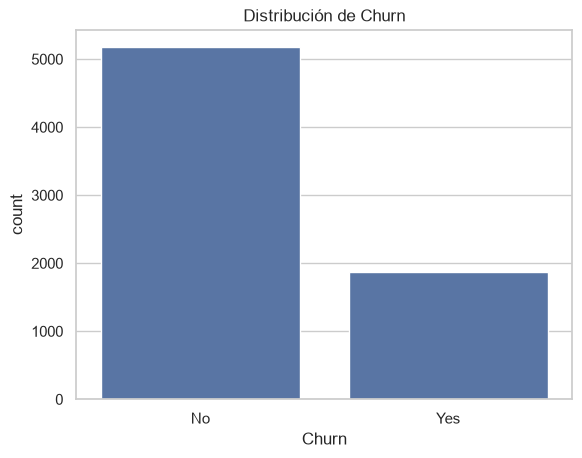

In [8]:
#la variable objetivo

conteo = df["Churn"].value_counts()
porcentaje = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([conteo, porcentaje], axis=1, keys=["clientes", "%"]))

sns.countplot(data=df, x="Churn")
plt.title("Distribución de Churn")
plt.show()

In [11]:
#un posible problema de calidad

total = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Valores no numéricos en TotalCharges:", total.isna().sum())
df.loc[total.isna(), ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores no numéricos en TotalCharges: 11


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
488,0,0,52.55,' ',No
753,0,0,20.25,' ',No
936,0,0,80.85,' ',No
1082,0,0,25.75,' ',No
1340,0,0,56.05,' ',No
3331,0,0,19.85,' ',No
3826,0,0,25.35,' ',No
4380,0,0,20.00,' ',No
5218,0,0,19.70,' ',No
6670,0,0,73.35,' ',No


# conclusiones

1. Desbalance de clases. El 26.5% de los clientes se fue y el 73.5% se quedó (aproximadamente 3 a 1). Un modelo que dijera siempre "No" acertaría el 73.5% sin aprender nada. Por eso más adelante no vamos a usar accuracy como métrica principal.

2. TotalCharges es texto. Aparece como str, aunque debería ser numérico. La causa son 11 filas con un valor vacío.

3. Esas 11 filas no son un error, tienen una explicación. Todas tienen tenure = 0: son clientes nuevos que todavía no han recibido su primera factura, y todos tienen Churn = No. Por eso TotalCharges está vacío. En el notebook 02 vamos a convertir esos valores a 0 en lugar de borrar las filas, porque el cliente existe y simplemente no ha pagado nada aún. Esta decisión, con su justificación, es justo lo que un reclutador quiere ver.



# Segunda parte

In [13]:
# Trabajamos sobre una copia: df (los datos crudos) no se toca
df_eda = df.copy()
df_eda["churn_bin"] = (df_eda["Churn"] == "Yes").astype(int)
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")